In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

# Global plot style
sns.set_theme(style="whitegrid", font_scale=1.1)
PALETTE = "Set2"
FIG_DPI = 130

print("All libraries imported successfully.")
print(f"pandas version  : {pd.__version__}")
print(f"numpy version   : {np.__version__}")
print(f"seaborn version : {sns.__version__}")


All libraries imported successfully.
pandas version  : 2.2.2
numpy version   : 2.0.2
seaborn version : 0.13.2


---
# TASK 2: Data Engineering & Preparation


## Step 1: Load Dataset

In [10]:
df_raw = pd.read_csv('/content/drive/MyDrive/EDA/owid-covid-data.csv')

print(f"Raw Shape        : {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
print(f"Date Range       : {df_raw['date'].min()} to {df_raw['date'].max()}")
print(f"Unique Locations : {df_raw['location'].nunique()}")
df_raw.head(3)


Raw Shape        : 350,085 rows x 67 columns
Date Range       : 2020-01-01 to 2023-10-24
Unique Locations : 255


,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-03,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-04,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-05,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Step 2: Remove Aggregated / Non-Country Rows
Rows without a `continent` value are world/regional aggregates (e.g. 'World', 'High income'). These must be removed to ensure we only analyse country-level data.


In [11]:
aggregated_locations = df_raw[df_raw['continent'].isna()]['location'].unique()
print(f"Removed locations: {list(aggregated_locations)}")

df = df_raw[df_raw['continent'].notna()].copy()
print(f"Shape after removal: {df.shape[0]:,} rows x {df.shape[1]} columns")


Removed locations: ['Africa', 'Asia', 'Europe', 'European Union', 'High income', 'Low income', 'Lower middle income', 'North America', 'Oceania', 'South America', 'Upper middle income', 'World']
Shape after removal: 333,420 rows x 67 columns


## Step 3: Convert Date Column to Datetime
Extract `year`, `month`, and `month_name` as new features for time-based analysis.


In [12]:
df['date']       = pd.to_datetime(df['date'])
df['year']       = df['date'].dt.year
df['month']      = df['date'].dt.month
df['month_name'] = df['date'].dt.strftime('%b')

print(f"Date dtype     : {df['date'].dtype}")
print(f"Years covered  : {sorted(df['year'].unique())}")


Date dtype     : datetime64[ns]
Years covered  : [np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023)]


## Step 4: Drop Columns with >70% Missing Values
**Assumption:** Columns with more than 70% missing data do not provide sufficient information for reliable analysis and are dropped.


In [13]:
threshold  = 0.70
missing_pct = df.isnull().mean()
cols_to_drop = missing_pct[missing_pct > threshold].index.tolist()

print(f"Columns dropped ({len(cols_to_drop)}):")
for c in cols_to_drop:
    print(f"  - {c} ({missing_pct[c]*100:.1f}% missing)")

df.drop(columns=cols_to_drop, inplace=True)
print(f"\nShape after drop: {df.shape[0]:,} rows x {df.shape[1]} columns")


Columns dropped (27):
  - icu_patients (88.7% missing)
  - icu_patients_per_million (88.7% missing)
  - hosp_patients (88.3% missing)
  - hosp_patients_per_million (88.3% missing)
  - weekly_icu_admissions (96.9% missing)
  - weekly_icu_admissions_per_million (96.9% missing)
  - weekly_hosp_admissions (93.0% missing)
  - weekly_hosp_admissions_per_million (93.0% missing)
  - total_tests (76.2% missing)
  - new_tests (77.4% missing)
  - total_tests_per_thousand (76.2% missing)
  - new_tests_per_thousand (77.4% missing)
  - positive_rate (71.2% missing)
  - tests_per_case (71.7% missing)
  - total_vaccinations (79.9% missing)
  - people_vaccinated (80.9% missing)
  - people_fully_vaccinated (81.8% missing)
  - total_boosters (89.0% missing)
  - new_vaccinations (84.0% missing)
  - total_vaccinations_per_hundred (79.9% missing)
  - people_vaccinated_per_hundred (80.9% missing)
  - people_fully_vaccinated_per_hundred (81.8% missing)
  - total_boosters_per_hundred (89.0% missing)
  - excess

## Step 5: Select Key Columns for Analysis

In [14]:
key_columns = [
    'iso_code', 'continent', 'location', 'date', 'year', 'month', 'month_name',
    'total_cases', 'new_cases', 'new_cases_smoothed',
    'total_deaths', 'new_deaths', 'new_deaths_smoothed',
    'total_cases_per_million', 'total_deaths_per_million',
    'reproduction_rate', 'stringency_index',
    'gdp_per_capita', 'life_expectancy', 'human_development_index',
    'median_age', 'population', 'population_density',
    'diabetes_prevalence', 'hospital_beds_per_thousand',
    'cardiovasc_death_rate',
]

key_columns = [c for c in key_columns if c in df.columns]
df = df[key_columns].copy()

print(f"Selected {len(key_columns)} columns:")
print(key_columns)


Selected 26 columns:
['iso_code', 'continent', 'location', 'date', 'year', 'month', 'month_name', 'total_cases', 'new_cases', 'new_cases_smoothed', 'total_deaths', 'new_deaths', 'new_deaths_smoothed', 'total_cases_per_million', 'total_deaths_per_million', 'reproduction_rate', 'stringency_index', 'gdp_per_capita', 'life_expectancy', 'human_development_index', 'median_age', 'population', 'population_density', 'diabetes_prevalence', 'hospital_beds_per_thousand', 'cardiovasc_death_rate']


## Step 6: Handle Missing Values
**Strategy:**
- `new_cases` / `new_deaths` → fill `0` (no report = no new case recorded)
- `total_cases` / `total_deaths` → forward fill per country (cumulative values persist)
- Socioeconomic columns → forward/backward fill per country (static annual values)
- `reproduction_rate` / `stringency_index` → linear interpolation per country


In [15]:
# Fill daily case/death NaN with 0
for col in ['new_cases', 'new_deaths', 'new_cases_smoothed', 'new_deaths_smoothed']:
    if col in df.columns:
        n = df[col].isna().sum()
        df[col] = df[col].fillna(0)
        print(f"  '{col}': filled {n:,} NaN -> 0")

# Forward fill cumulative totals per country
df.sort_values(['location', 'date'], inplace=True)
for col in ['total_cases', 'total_deaths', 'total_cases_per_million', 'total_deaths_per_million']:
    if col in df.columns:
        n = df[col].isna().sum()
        df[col] = df.groupby('location')[col].ffill().fillna(0)
        print(f"  '{col}': forward-filled {n:,} NaN per country")

# Fill static socioeconomic columns
socio_cols = ['gdp_per_capita', 'life_expectancy', 'human_development_index',
              'median_age', 'population_density', 'diabetes_prevalence',
              'hospital_beds_per_thousand', 'cardiovasc_death_rate']
for col in socio_cols:
    if col in df.columns:
        n = df[col].isna().sum()
        df[col] = df.groupby('location')[col].ffill().bfill()
        print(f"  '{col}': ffill/bfill {n:,} NaN")

# Interpolate time-series policy/rate columns
for col in ['stringency_index', 'reproduction_rate']:
    if col in df.columns:
        n = df[col].isna().sum()
        df[col] = df.groupby('location')[col].transform(
            lambda x: x.interpolate(method='linear').ffill().bfill()
        )
        print(f"  '{col}': interpolated {n:,} NaN")


  'new_cases': filled 9,583 NaN -> 0
  'new_deaths': filled 9,529 NaN -> 0
  'new_cases_smoothed': filled 10,782 NaN -> 0
  'new_deaths_smoothed': filled 10,699 NaN -> 0
  'total_cases': forward-filled 37,734 NaN per country
  'total_deaths': forward-filled 59,171 NaN per country
  'total_cases_per_million': forward-filled 37,734 NaN per country
  'total_deaths_per_million': forward-filled 59,171 NaN per country
  'gdp_per_capita': ffill/bfill 63,947 NaN
  'life_expectancy': ffill/bfill 12,738 NaN
  'human_development_index': ffill/bfill 71,672 NaN
  'median_age': ffill/bfill 58,443 NaN
  'population_density': ffill/bfill 37,632 NaN
  'diabetes_prevalence': ffill/bfill 49,507 NaN
  'hospital_beds_per_thousand': ffill/bfill 95,141 NaN
  'cardiovasc_death_rate': ffill/bfill 63,323 NaN
  'stringency_index': interpolated 135,769 NaN
  'reproduction_rate': interpolated 149,679 NaN


## Step 7: Remove Erroneous Negative Values
Some reporting corrections cause negative `new_cases` / `new_deaths`. These are clipped to 0.


In [16]:
for col in ['new_cases', 'new_deaths', 'total_cases', 'total_deaths']:
    if col in df.columns:
        neg = (df[col] < 0).sum()
        df[col] = df[col].clip(lower=0)
        print(f"  '{col}': clipped {neg:,} negative values to 0")


  'new_cases': clipped 0 negative values to 0
  'new_deaths': clipped 0 negative values to 0
  'total_cases': clipped 0 negative values to 0
  'total_deaths': clipped 0 negative values to 0


## Step 8: Feature Engineering
Creating 4 new derived features for deeper analysis.


In [17]:
# Case Fatality Rate (CFR)
df['case_fatality_rate'] = np.where(
    df['total_cases'] > 0,
    (df['total_deaths'] / df['total_cases'] * 100).round(4),
    0
)
print("Created: 'case_fatality_rate' = (total_deaths / total_cases) * 100")

# Deaths per 100k population
df['deaths_per_100k'] = np.where(
    df['population'] > 0,
    (df['total_deaths'] / df['population'] * 100000).round(4),
    0
)
print("Created: 'deaths_per_100k' = (total_deaths / population) * 100,000")

# GDP Income group
gdp_bins   = [0, 5000, 15000, 40000, float('inf')]
gdp_labels = ['Low Income', 'Lower-Middle', 'Upper-Middle', 'High Income']
df['gdp_group'] = pd.cut(df['gdp_per_capita'], bins=gdp_bins, labels=gdp_labels)
print("Created: 'gdp_group' — 4 income categories")

# Month-Year label
df['month_year'] = df['date'].dt.to_period('M').astype(str)
print("Created: 'month_year' — e.g. '2021-03'")

df[['case_fatality_rate', 'deaths_per_100k', 'gdp_group', 'month_year']].head(5)


Created: 'case_fatality_rate' = (total_deaths / total_cases) * 100
Created: 'deaths_per_100k' = (total_deaths / population) * 100,000
Created: 'gdp_group' — 4 income categories
Created: 'month_year' — e.g. '2021-03'


,case_fatality_rate,deaths_per_100k,gdp_group,month_year
0,0.0,0.0,Low Income,2020-01
1,0.0,0.0,Low Income,2020-01
2,0.0,0.0,Low Income,2020-01
3,0.0,0.0,Low Income,2020-01
4,0.0,0.0,Low Income,2020-01


## Step 9: Data Reshaping

In [18]:
# Pivot: total new cases per continent per year
pivot_cases = df.groupby(['continent', 'year'])['new_cases'].sum().reset_index()
pivot_cases = pivot_cases.pivot(index='continent', columns='year', values='new_cases')
pivot_cases.columns.name = None
pivot_cases = pivot_cases.fillna(0).astype(int)
print("Pivot table — New cases per Continent per Year:")
print(pivot_cases)

# Monthly global aggregation
monthly_global = df.groupby('month_year').agg(
    total_new_cases  = ('new_cases', 'sum'),
    total_new_deaths = ('new_deaths', 'sum'),
    avg_reproduction = ('reproduction_rate', 'mean'),
    avg_stringency   = ('stringency_index', 'mean')
).reset_index()
print(f"\nMonthly global data: {monthly_global.shape[0]} months")

# Country snapshot (latest record per country)
snapshot = df.sort_values('date').groupby('location').last().reset_index()
print(f"Country snapshot  : {snapshot.shape[0]} countries")


Pivot table — New cases per Continent per Year:
                   2020      2021       2022      2023
continent                                             
Africa          2747852   7103383    3149989    114169
Asia           20502423  64144815  189920775  26179853
Europe         23229750  63192836  155893782   7467387
North America  22699780  41404408   55401903   4991949
Oceania           55184    493724   12770121   1180519
South America  13112340  26773660   26894317   2062944

Monthly global data: 46 months
Country snapshot  : 243 countries


## Step 10: Final Validation & Save

In [19]:
print(f"Final shape      : {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Remaining NaN    : {df.isnull().sum().sum():,}")
print(f"Countries        : {df['location'].nunique()}")
print(f"Date range       : {df['date'].min().date()} to {df['date'].max().date()}")

# Save cleaned datasets
df.to_csv('covid_cleaned.csv', index=False)
monthly_global.to_csv('covid_monthly_global.csv', index=False)
snapshot.to_csv('covid_country_snapshot.csv', index=False)
pivot_cases.to_csv('covid_pivot_continent_year.csv')

print("\nSaved:")
print("  covid_cleaned.csv")
print("  covid_monthly_global.csv")
print("  covid_country_snapshot.csv")
print("  covid_pivot_continent_year.csv")

df.info()


Final shape      : 333,420 rows x 30 columns
Remaining NaN    : 142,542
Countries        : 243
Date range       : 2020-01-01 to 2023-10-24

Saved:
  covid_cleaned.csv
  covid_monthly_global.csv
  covid_country_snapshot.csv
  covid_pivot_continent_year.csv
<class 'pandas.core.frame.DataFrame'>
Index: 333420 entries, 0 to 350084
Data columns (total 30 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   iso_code                    333420 non-null  object        
 1   continent                   333420 non-null  object        
 2   location                    333420 non-null  object        
 3   date                        333420 non-null  datetime64[ns]
 4   year                        333420 non-null  int32         
 5   month                       333420 non-null  int32         
 6   month_name                  333420 non-null  object        
 7   total_cases                 333420 non-null  flo

---
# TASK 3: Exploratory Data Analysis (EDA)




## Chart 1 — Line Chart: Global Daily New Cases Over Time
**Finding:** Three distinct pandemic waves are visible. The Omicron wave (early 2022) was the largest globally, dwarfing earlier waves. The steep decline after each wave reflects a combination of natural immunity, vaccination rollouts, and policy interventions.


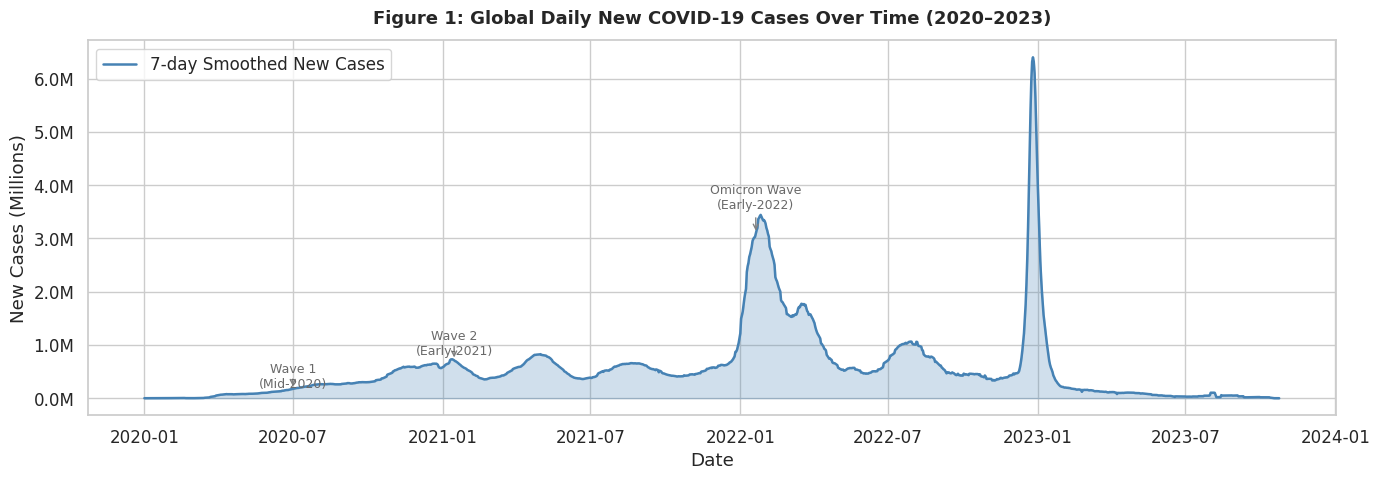

In [20]:
fig, ax = plt.subplots(figsize=(14, 5))

global_daily = df.groupby('date')['new_cases_smoothed'].sum().reset_index()

ax.fill_between(global_daily['date'], global_daily['new_cases_smoothed'],
                alpha=0.25, color='steelblue')
ax.plot(global_daily['date'], global_daily['new_cases_smoothed'],
        color='steelblue', linewidth=1.8, label='7-day Smoothed New Cases')

waves = {
    'Wave 1\n(Mid-2020)': '2020-07-01',
    'Wave 2\n(Early-2021)': '2021-01-15',
    'Omicron Wave\n(Early-2022)': '2022-01-20',
}
for label, date_str in waves.items():
    x = pd.Timestamp(date_str)
    y = global_daily.loc[global_daily['date'] == global_daily['date']
                         .iloc[(global_daily['date'] - x).abs().argsort()[:1]].values[0],
                         'new_cases_smoothed'].values[0]
    ax.annotate(label, xy=(x, y), xytext=(x, y * 1.15),
                arrowprops=dict(arrowstyle='->', color='gray'),
                fontsize=9, ha='center', color='dimgray')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.set_title('Figure 1: Global Daily New COVID-19 Cases Over Time (2020–2023)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Date')
ax.set_ylabel('New Cases (Millions)')
ax.legend()
plt.tight_layout()
plt.savefig('chart1_line_global_cases.png', dpi=130, bbox_inches='tight')
plt.show()


## Chart 2 — Bar Chart: Top 15 Countries by Total Deaths
**Finding:** The United States, Brazil, and India account for the largest share of global COVID-19 deaths. This reflects both large population sizes and early healthcare system strain. European nations like Russia and the United Kingdom also feature prominently, suggesting that wealth alone did not prevent high death tolls.


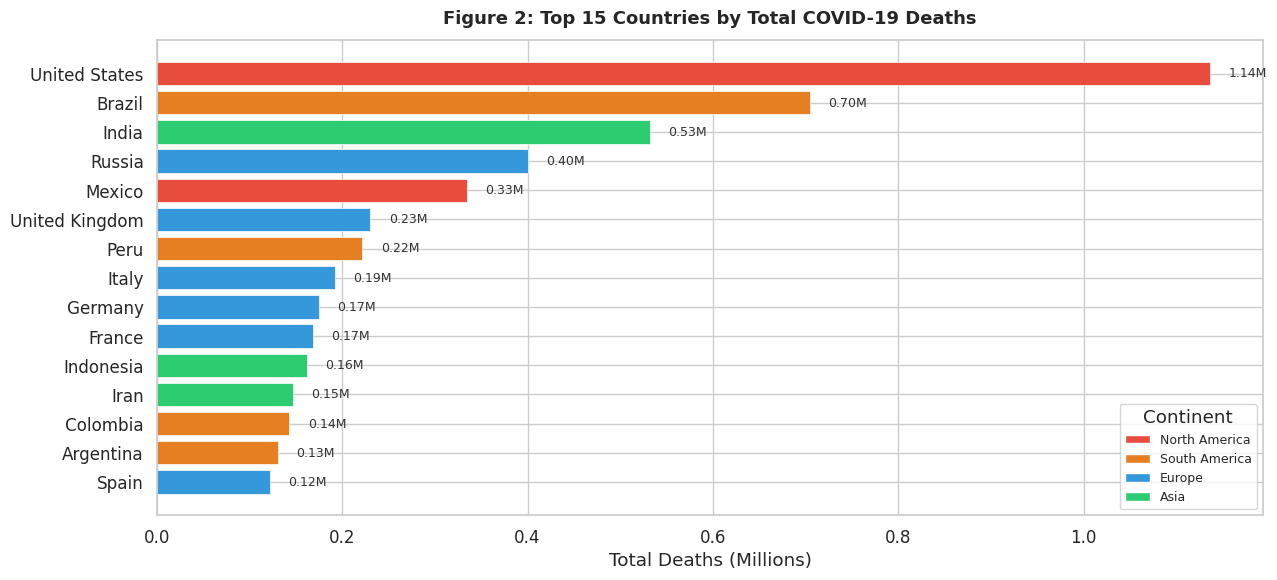

In [21]:
top15 = (snapshot.nlargest(15, 'total_deaths')
         [['location', 'total_deaths', 'continent']].reset_index(drop=True))

continent_colors = {
    'North America': '#e74c3c', 'South America': '#e67e22',
    'Europe': '#3498db',        'Asia': '#2ecc71',
    'Africa': '#9b59b6',        'Oceania': '#1abc9c'
}
bar_colors = [continent_colors.get(c, '#95a5a6') for c in top15['continent']]

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.barh(top15['location'], top15['total_deaths'] / 1e6,
               color=bar_colors, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, top15['total_deaths']):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
            f'{val/1e6:.2f}M', va='center', fontsize=9, color='#333')

ax.set_title('Figure 2: Top 15 Countries by Total COVID-19 Deaths',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Total Deaths (Millions)')
ax.invert_yaxis()

legend_elements = [Patch(facecolor=v, label=k) for k, v in continent_colors.items()
                   if k in top15['continent'].values]
ax.legend(handles=legend_elements, title='Continent', fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig('chart2_bar_top15_deaths.png', dpi=130, bbox_inches='tight')
plt.show()


## Chart 3 — Heatmap: Correlation Between Key Variables
**Finding:** Median age and HDI show a strong positive correlation with deaths per million, suggesting that older and more developed nations reported higher death rates — likely due to better data collection. Conversely, hospital beds per thousand shows a weak correlation with outcomes, indicating that infrastructure alone was insufficient without pandemic preparedness.


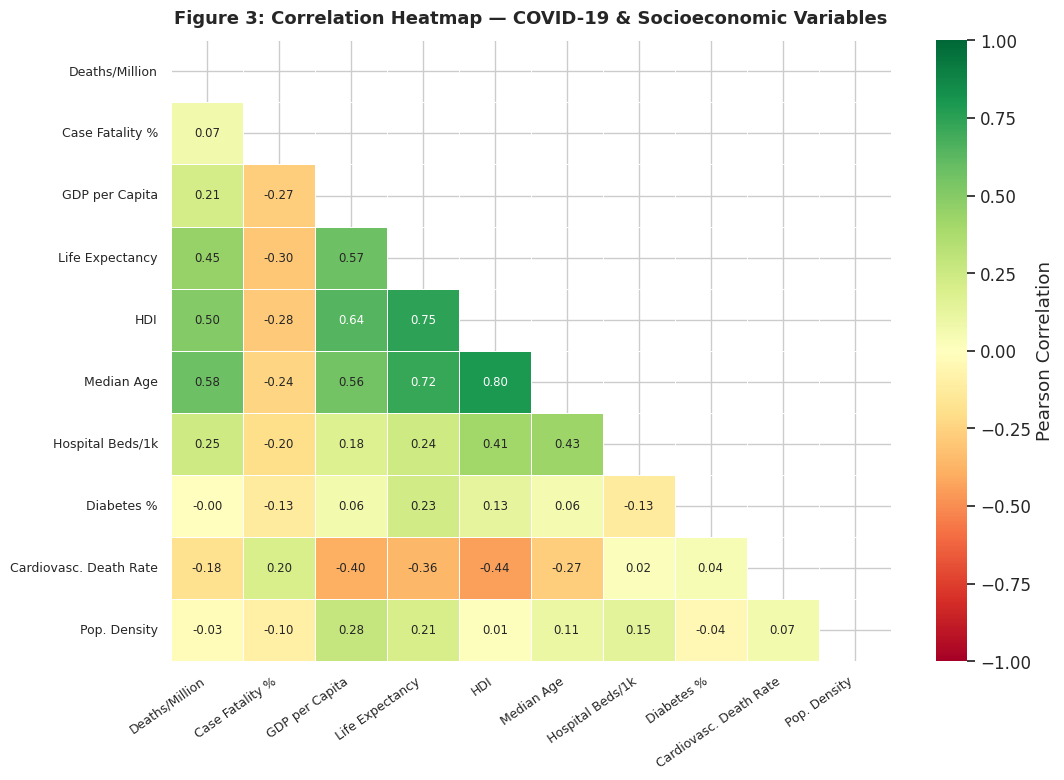

In [22]:
corr_cols = {
    'total_deaths_per_million': 'Deaths/Million',
    'case_fatality_rate':       'Case Fatality %',
    'gdp_per_capita':           'GDP per Capita',
    'life_expectancy':          'Life Expectancy',
    'human_development_index':  'HDI',
    'median_age':               'Median Age',
    'hospital_beds_per_thousand': 'Hospital Beds/1k',
    'diabetes_prevalence':      'Diabetes %',
    'cardiovasc_death_rate':    'Cardiovasc. Death Rate',
    'population_density':       'Pop. Density',
}

corr_df = snapshot[[c for c in corr_cols.keys() if c in snapshot.columns]].copy()
corr_df.columns = [corr_cols[c] for c in corr_df.columns]
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={'size': 8.5},
            cbar_kws={'label': 'Pearson Correlation'})
ax.set_title('Figure 3: Correlation Heatmap — COVID-19 & Socioeconomic Variables',
             fontsize=13, fontweight='bold', pad=12)
plt.xticks(rotation=35, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('chart3_heatmap_correlation.png', dpi=130, bbox_inches='tight')
plt.show()


## Chart 4 — Scatter Plot: GDP per Capita vs Deaths per Million
**Finding:** Wealthier nations paradoxically report more deaths per million — a finding known as the "reporting paradox." High-income countries have more robust death registration systems. Low-income nations such as those in Africa likely have significant underreporting. Notable outliers include Peru (highest deaths per million despite moderate GDP) and China (low reported deaths despite large population).


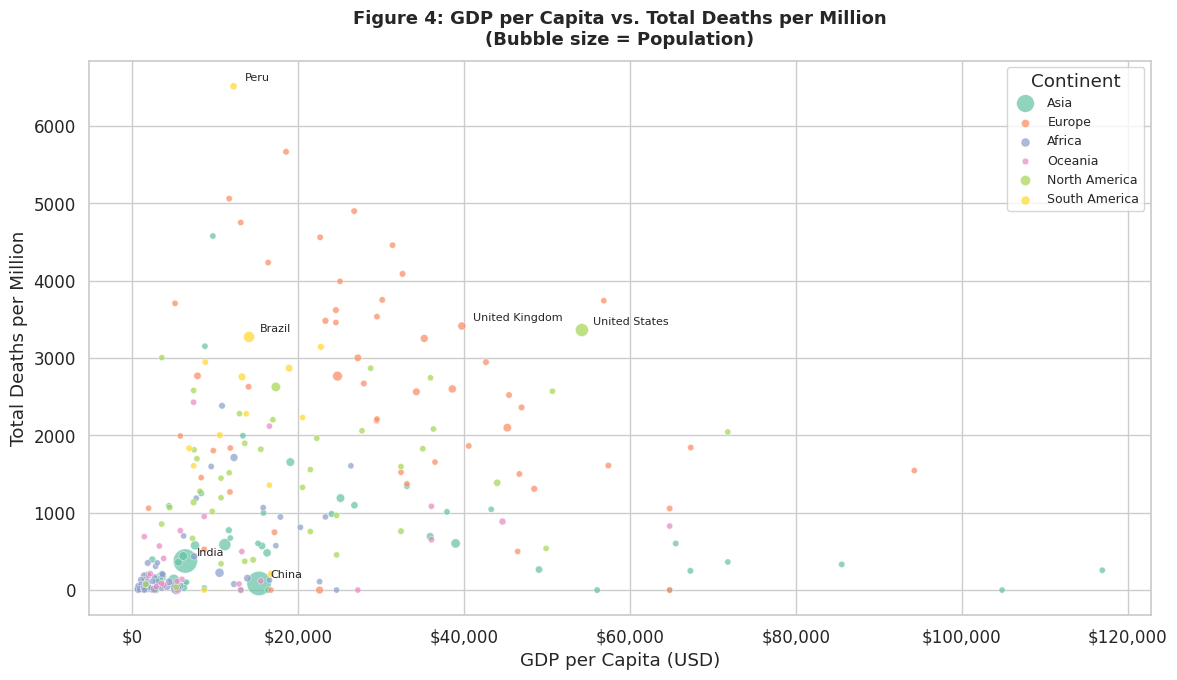

In [23]:
scatter_df = snapshot.dropna(subset=['gdp_per_capita', 'total_deaths_per_million',
                                      'continent', 'population']).copy()

fig, ax = plt.subplots(figsize=(12, 7))
continents = scatter_df['continent'].unique()
palette    = sns.color_palette(PALETTE, len(continents))

for cont, color in zip(continents, palette):
    sub = scatter_df[scatter_df['continent'] == cont]
    ax.scatter(sub['gdp_per_capita'], sub['total_deaths_per_million'],
               label=cont, color=color, alpha=0.72,
               s=sub['population'] / 5e6 + 20,
               edgecolors='white', linewidth=0.4)

notable = ['United States', 'Brazil', 'India', 'Peru', 'United Kingdom', 'China']
for _, row in scatter_df[scatter_df['location'].isin(notable)].iterrows():
    ax.annotate(row['location'],
                xy=(row['gdp_per_capita'], row['total_deaths_per_million']),
                xytext=(8, 4), textcoords='offset points', fontsize=8)

ax.set_title('Figure 4: GDP per Capita vs. Total Deaths per Million\n(Bubble size = Population)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('GDP per Capita (USD)')
ax.set_ylabel('Total Deaths per Million')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(title='Continent', fontsize=9)
plt.tight_layout()
plt.savefig('chart4_scatter_gdp_deaths.png', dpi=130, bbox_inches='tight')
plt.show()


## Chart 5 — Box Plot: Case Fatality Rate by Continent
**Finding:** Africa and Asia show higher median case fatality rates with wider distributions. This likely reflects limited testing capacity — fewer tests mean only severe cases are counted, inflating the CFR. Europe shows a tighter distribution with lower median CFR, consistent with widespread testing and better healthcare infrastructure. Outliers across all continents indicate countries with extreme reporting inconsistencies.


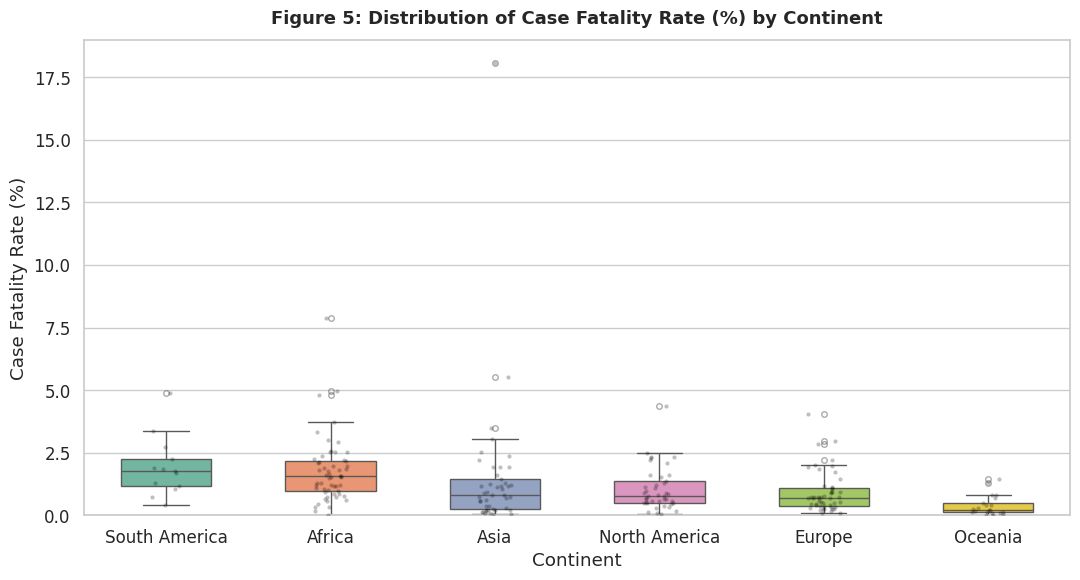

In [24]:
box_df = snapshot[snapshot['case_fatality_rate'] > 0].copy()
order  = (box_df.groupby('continent')['case_fatality_rate']
          .median().sort_values(ascending=False).index.tolist())

fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(data=box_df, x='continent', y='case_fatality_rate',
            order=order, palette=PALETTE, width=0.55,
            flierprops=dict(marker='o', markersize=4, alpha=0.5), ax=ax)
sns.stripplot(data=box_df, x='continent', y='case_fatality_rate',
              order=order, color='black', alpha=0.25, size=3, jitter=True, ax=ax)

ax.set_title('Figure 5: Distribution of Case Fatality Rate (%) by Continent',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Continent')
ax.set_ylabel('Case Fatality Rate (%)')
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig('chart5_boxplot_cfr_continent.png', dpi=130, bbox_inches='tight')
plt.show()


## Chart 6 — Histogram: Distribution of Reproduction Rate (R)
**Finding:** The majority of R values cluster just above 1.0, meaning the virus was consistently on the threshold of epidemic growth. The bimodal distribution (a smaller green peak below 1 and a larger red peak above 1) reflects alternating phases of lockdowns (R < 1) and relaxation (R > 1). The mean R value above 1.0 confirms the virus was predominantly in a spreading phase throughout the study period.


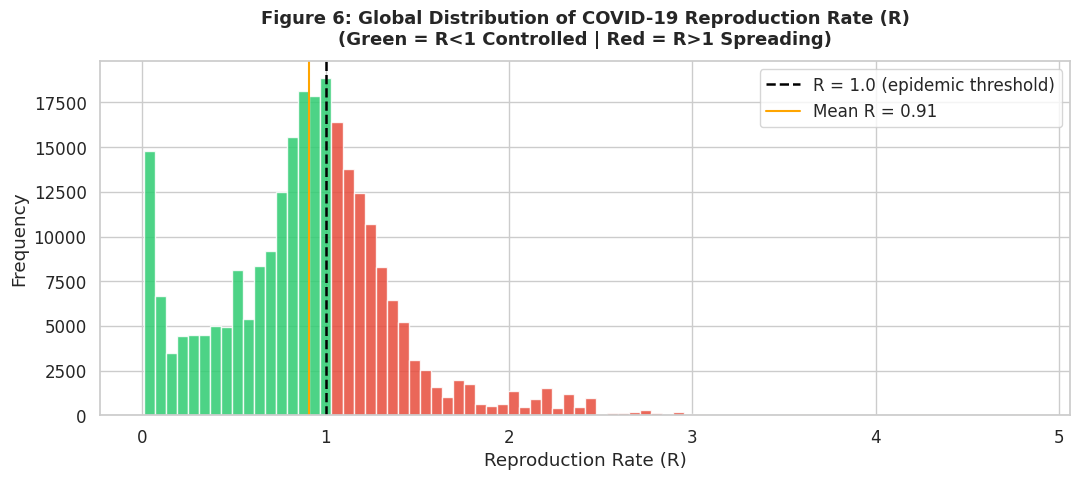

In [25]:
r_vals = df['reproduction_rate'].dropna()
r_vals = r_vals[(r_vals > 0) & (r_vals < 5)]

fig, ax = plt.subplots(figsize=(11, 5))
n, bins, patches = ax.hist(r_vals, bins=80, color='steelblue',
                            edgecolor='white', alpha=0.85)

for patch, left in zip(patches, bins[:-1]):
    patch.set_facecolor('#e74c3c' if left >= 1.0 else '#2ecc71')

ax.axvline(x=1.0, color='black', linestyle='--', linewidth=1.8,
           label='R = 1.0 (epidemic threshold)')
ax.axvline(x=r_vals.mean(), color='orange', linestyle='-', linewidth=1.5,
           label=f'Mean R = {r_vals.mean():.2f}')

ax.set_title('Figure 6: Global Distribution of COVID-19 Reproduction Rate (R)\n'
             '(Green = R<1 Controlled | Red = R>1 Spreading)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Reproduction Rate (R)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.savefig('chart6_histogram_reproduction_rate.png', dpi=130, bbox_inches='tight')
plt.show()


## Chart 7 — Stacked Area Chart (Bonus): Cases by Continent Over Time
**Finding:** Asia and Europe dominated the Omicron wave of early 2022. Africa's consistently low share throughout all waves is a significant anomaly — rather than indicating low transmission, this likely reflects severely limited testing capacity and underreporting infrastructure in many African nations, representing a key data bias that must be acknowledged.


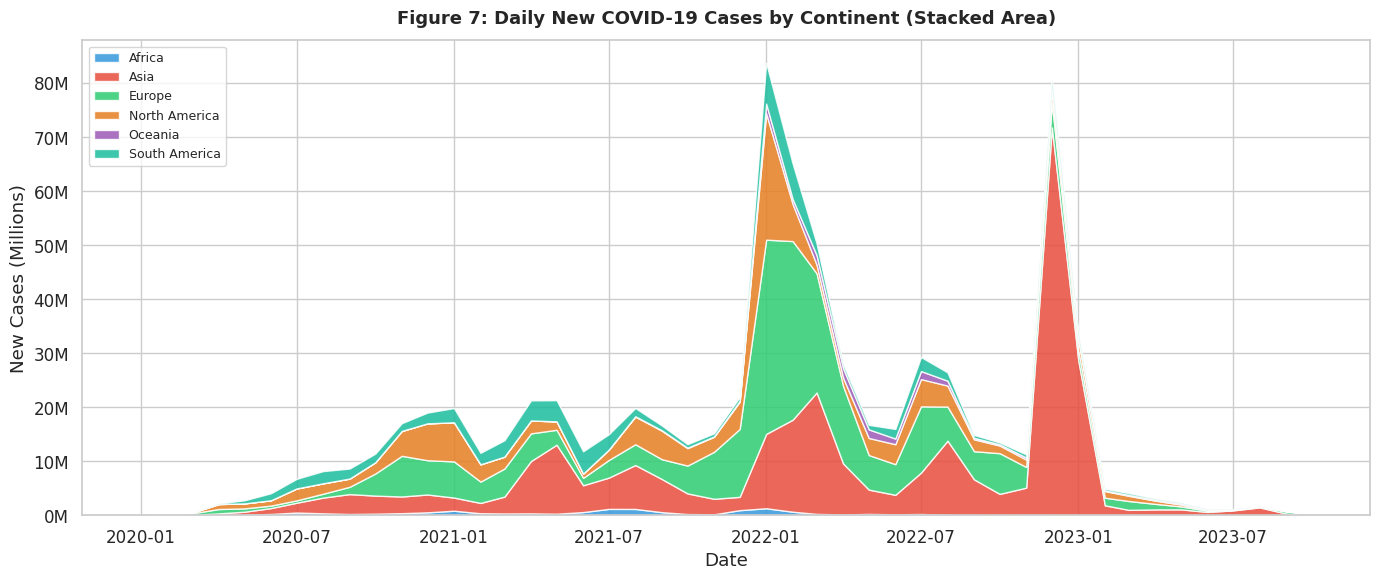

In [26]:
continent_monthly = (df.groupby(['month_year', 'continent'])['new_cases_smoothed']
                     .sum().reset_index())
pivot_cm = continent_monthly.pivot(index='month_year', columns='continent',
                                    values='new_cases_smoothed').fillna(0)
pivot_cm.index = pd.PeriodIndex(pivot_cm.index, freq='M').to_timestamp()
pivot_cm = pivot_cm.sort_index()

fig, ax = plt.subplots(figsize=(14, 6))
cont_colors = ['#3498db', '#e74c3c', '#2ecc71', '#e67e22', '#9b59b6', '#1abc9c']
ax.stackplot(pivot_cm.index, pivot_cm.T.values,
             labels=pivot_cm.columns, colors=cont_colors, alpha=0.85)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
ax.set_title('Figure 7: Daily New COVID-19 Cases by Continent (Stacked Area)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Date')
ax.set_ylabel('New Cases (Millions)')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('chart7_stacked_area_continent.png', dpi=130, bbox_inches='tight')
plt.show()


## EDA Summary

In [27]:
summary = pd.DataFrame({
    'Chart'  : ['Chart 1','Chart 2','Chart 3','Chart 4','Chart 5','Chart 6','Chart 7'],
    'Type'   : ['Line','Bar','Heatmap','Scatter','Box Plot','Histogram','Stacked Area'],
    'Key Finding': [
        'Omicron wave (2022) was the largest global COVID spike',
        'USA, Brazil, India lead in total deaths',
        'Median age & HDI positively correlated with deaths/million',
        'Wealthier nations report higher deaths/million (reporting paradox)',
        'Africa & Asia show higher CFR — likely due to low testing rates',
        'Most R values cluster just above 1.0 (persistently spreading)',
        'Africa consistently underrepresented — possible data bias'
    ]
})
print(summary.to_string(index=False))


  Chart         Type                                                        Key Finding
Chart 1         Line             Omicron wave (2022) was the largest global COVID spike
Chart 2          Bar                            USA, Brazil, India lead in total deaths
Chart 3      Heatmap         Median age & HDI positively correlated with deaths/million
Chart 4      Scatter Wealthier nations report higher deaths/million (reporting paradox)
Chart 5     Box Plot    Africa & Asia show higher CFR — likely due to low testing rates
Chart 6    Histogram      Most R values cluster just above 1.0 (persistently spreading)
Chart 7 Stacked Area          Africa consistently underrepresented — possible data bias
